### FINE-TUNING RESNET-18

In [4]:
# Import libraries
from pathlib import Path
import sys
import random
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader


In [5]:
# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "checkpoints"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

METRICS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "fine_tuning.yaml"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", PROJECT_ROOT)
print("Fine-tuning config:", CONFIG_PATH)


Project root: c:\Deep Learning\skin-lesion-classification
Fine-tuning config: c:\Deep Learning\skin-lesion-classification\configs\fine_tuning.yaml


In [7]:
# ------------------------------------------------------------
# Import project modules
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

from src.data.dataset import (
    HAM10000Dataset,
    HAM10000_CLASSES,
)

from src.data.preprocessing import (
    get_eval_transform,
)

from src.data.augmentation import (
    get_train_transform,
)

from src.models.transfer_learning import (
    TransferLearningResNet18,
)

from src.training.losses import (
    compute_class_weights,
)

from src.training.train import (
    fit,
)

from src.models.fine_tuning import (
    configure_resnet18_fine_tuning,
    get_fine_tuning_criterion,
    get_fine_tuning_optimizer,
    get_fine_tuning_scheduler,
    count_trainable_parameters,
)


In [8]:
# ------------------------------------------------------------
# Load fine-tuning configuration
# ------------------------------------------------------------

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Fine-tuning config not found: {CONFIG_PATH}\n"
        "Create configs/fine_tuning.yaml before running Part 8."
    )

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    config = yaml.safe_load(file)

config


{'experiment': {'name': 'fine_tuned_resnet18', 'seed': 42},
 'data': {'image_size': 224,
  'batch_size': 32,
  'num_workers': 0,
  'num_classes': 7},
 'model': {'name': 'resnet18',
  'pretrained': True,
  'dropout': 0.3,
  'checkpoint': 'outputs/checkpoints/transfer_resnet18_best.pt'},
 'fine_tuning': {'strategy': 'progressive',
  'frozen_modules': ['conv1', 'bn1', 'layer1', 'layer2', 'layer3'],
  'trainable_modules': ['layer4', 'fc']},
 'loss': {'name': 'weighted_cross_entropy',
  'class_weight_strategy': 'sqrt_inverse_frequency',
  'label_smoothing': 0.05},
 'optimizer': {'name': 'AdamW',
  'backbone_lr': 1e-05,
  'classifier_lr': 0.0001,
  'weight_decay': 0.0001},
 'scheduler': {'name': 'ReduceLROnPlateau',
  'mode': 'min',
  'factor': 0.5,
  'patience': 2,
  'min_lr': 1e-07},
 'training': {'epochs': 15,
  'early_stopping_patience': 5,
  'monitor': 'val_loss'},
 'outputs': {'checkpoint': 'outputs/checkpoints/fine_tuned_resnet18_best.pt',
  'history': 'outputs/metrics/fine_tuned_resn

In [9]:
# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = config["experiment"]["seed"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)


Random seed: 42


In [10]:
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )


Using device: cpu


In [11]:
# ------------------------------------------------------------
# Load the fixed Train / Validation / Test split
# ------------------------------------------------------------

train_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "train.csv"
)

val_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "val.csv"
)

test_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "test.csv"
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 6981
Validation: 1532
Test: 1502


## Important: role of the validation and test sets

The **validation set** is used during fine-tuning for model selection, learning-rate
scheduling, and early stopping.

The **test set is not used in this notebook for model selection**. It is loaded only
to preserve the same project pipeline and will be used in Part 9 — Evaluation after
all models have been finalized.


In [12]:
# ------------------------------------------------------------
# Image transforms
# ------------------------------------------------------------

IMAGE_SIZE = config["data"]["image_size"]

train_transform = get_train_transform(
    image_size=IMAGE_SIZE,
)

eval_transform = get_eval_transform(
    image_size=IMAGE_SIZE,
)

print("Image size:", IMAGE_SIZE)


Image size: 224


In [13]:
# ------------------------------------------------------------
# Datasets
# ------------------------------------------------------------

train_dataset = HAM10000Dataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    transform=train_transform,
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)


In [14]:
# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = config["data"]["batch_size"]
NUM_WORKERS = config["data"]["num_workers"]

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Batch size:", BATCH_SIZE)


Batch size: 32


In [15]:
# ------------------------------------------------------------
# Initialize ResNet-18 architecture
# ------------------------------------------------------------

NUM_CLASSES = config["data"]["num_classes"]
DROPOUT = config["model"]["dropout"]

model = TransferLearningResNet18(
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    pretrained=True,
    freeze_backbone=True,
)

model = model.to(device)

print(model)


TransferLearningResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(

In [16]:
# ------------------------------------------------------------
# Load the BEST transfer-learning checkpoint from Part 7
# ------------------------------------------------------------

TRANSFER_CHECKPOINT = (
    PROJECT_ROOT
    / config["model"]["checkpoint"]
)

if not TRANSFER_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Transfer-learning checkpoint not found:\n"
        f"{TRANSFER_CHECKPOINT}\n\n"
        "Run Part 7 first and make sure "
        "transfer_resnet18_best.pt has been saved."
    )

model.load_state_dict(
    torch.load(
        TRANSFER_CHECKPOINT,
        map_location=device,
    )
)

print(
    "Loaded transfer-learning checkpoint:",
    TRANSFER_CHECKPOINT,
)


Loaded transfer-learning checkpoint: c:\Deep Learning\skin-lesion-classification\outputs\checkpoints\transfer_resnet18_best.pt


In [17]:
# ------------------------------------------------------------
# Configure progressive fine-tuning
# ------------------------------------------------------------

model = configure_resnet18_fine_tuning(
    model
)

stats = count_trainable_parameters(
    model
)

print(
    f"Total parameters:     "
    f"{stats['total']:,}"
)

print(
    f"Trainable parameters: "
    f"{stats['trainable']:,}"
)

print(
    f"Frozen parameters:    "
    f"{stats['frozen']:,}"
)

print(
    f"Trainable ratio:      "
    f"{stats['trainable_ratio'] * 100:.2f}%"
)

print("\nTrainable parameter groups:")

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)


Total parameters:     11,180,103
Trainable parameters: 8,397,319
Frozen parameters:    2,782,784
Trainable ratio:      75.11%

Trainable parameter groups:
backbone.layer4.0.conv1.weight
backbone.layer4.0.bn1.weight
backbone.layer4.0.bn1.bias
backbone.layer4.0.conv2.weight
backbone.layer4.0.bn2.weight
backbone.layer4.0.bn2.bias
backbone.layer4.0.downsample.0.weight
backbone.layer4.0.downsample.1.weight
backbone.layer4.0.downsample.1.bias
backbone.layer4.1.conv1.weight
backbone.layer4.1.bn1.weight
backbone.layer4.1.bn1.bias
backbone.layer4.1.conv2.weight
backbone.layer4.1.bn2.weight
backbone.layer4.1.bn2.bias
backbone.fc.1.weight
backbone.fc.1.bias


### Fine-tuning scope

Only the following components are updated:

- `layer4` — the final ResNet-18 residual stage
- `fc` — the seven-class classification head

The earlier layers remain frozen. This preserves general ImageNet visual features
while allowing high-level representations to adapt to HAM10000 dermoscopic images.


In [18]:
# ------------------------------------------------------------
# Class weights
# ------------------------------------------------------------

raw_class_weights = compute_class_weights(
    train_df=train_df,
    class_names=HAM10000_CLASSES,
    device=device,
)

criterion_ft, fine_tune_class_weights = (
    get_fine_tuning_criterion(
        raw_class_weights=raw_class_weights,
        label_smoothing=config["loss"]["label_smoothing"],
    )
)

print("Original class weights:")
print(raw_class_weights)

print("\nSoftened fine-tuning class weights:")
print(fine_tune_class_weights)

print("\nCriterion:")
print(criterion_ft)


Original class weights:
tensor([ 4.4923,  2.7626,  1.2918, 14.0463,  1.2901,  0.2130, 10.0736])

Softened fine-tuning class weights:
tensor([2.1195, 1.6621, 1.1366, 3.7478, 1.1358, 0.4615, 3.1739])

Criterion:
CrossEntropyLoss()


In [19]:
# ------------------------------------------------------------
# Optimizer with discriminative learning rates
# ------------------------------------------------------------

optimizer_ft = get_fine_tuning_optimizer(
    model=model,
    backbone_lr=config["optimizer"]["backbone_lr"],
    classifier_lr=config["optimizer"]["classifier_lr"],
    weight_decay=config["optimizer"]["weight_decay"],
)

print(
    "Backbone LR:",
    config["optimizer"]["backbone_lr"],
)

print(
    "Classifier LR:",
    config["optimizer"]["classifier_lr"],
)

print(optimizer_ft)


Backbone LR: 1e-05
Classifier LR: 0.0001
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [20]:
# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler_ft = get_fine_tuning_scheduler(
    optimizer=optimizer_ft,
    factor=config["scheduler"]["factor"],
    patience=config["scheduler"]["patience"],
    min_lr=config["scheduler"]["min_lr"],
)

print(scheduler_ft)


In [21]:
# ------------------------------------------------------------
# Fine-tune ResNet-18
# ------------------------------------------------------------

FINE_TUNED_CHECKPOINT = (
    PROJECT_ROOT
    / config["outputs"]["checkpoint"]
)

FINE_TUNING_HISTORY = (
    PROJECT_ROOT
    / config["outputs"]["history"]
)

fine_tune_history_df = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_ft,
    optimizer=optimizer_ft,
    device=device,
    num_epochs=config["training"]["epochs"],
    checkpoint_path=FINE_TUNED_CHECKPOINT,
    scheduler=scheduler_ft,
    early_stopping_patience=(
        config["training"]["early_stopping_patience"]
    ),
    history_path=FINE_TUNING_HISTORY,
)

print(
    "Fine-tuning completed."
)


Epoch 01/15 | Train Loss: 1.5016 | Train Acc: 0.6737 | Val Loss: 1.4458 | Val Acc: 0.7004 | LR: 0.000010
  -> Best model saved.
Epoch 02/15 | Train Loss: 1.4162 | Train Acc: 0.7055 | Val Loss: 1.4037 | Val Acc: 0.7128 | LR: 0.000010
  -> Best model saved.
Epoch 03/15 | Train Loss: 1.3785 | Train Acc: 0.7162 | Val Loss: 1.3856 | Val Acc: 0.7258 | LR: 0.000010
  -> Best model saved.
Epoch 04/15 | Train Loss: 1.3420 | Train Acc: 0.7235 | Val Loss: 1.3646 | Val Acc: 0.7330 | LR: 0.000010
  -> Best model saved.
Epoch 05/15 | Train Loss: 1.3166 | Train Acc: 0.7338 | Val Loss: 1.3543 | Val Acc: 0.7317 | LR: 0.000010
  -> Best model saved.
Epoch 06/15 | Train Loss: 1.3035 | Train Acc: 0.7396 | Val Loss: 1.3129 | Val Acc: 0.7500 | LR: 0.000010
  -> Best model saved.
Epoch 07/15 | Train Loss: 1.2750 | Train Acc: 0.7423 | Val Loss: 1.3033 | Val Acc: 0.7552 | LR: 0.000010
  -> Best model saved.
Epoch 08/15 | Train Loss: 1.2452 | Train Acc: 0.7579 | Val Loss: 1.2950 | Val Acc: 0.7617 | LR: 0.000010

In [22]:
# Training history
fine_tune_history_df


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1.501601,0.673686,1.445755,0.700392,0.00001
1,2,1.416191,0.705486,1.403670,0.712794,0.00001
2,3,1.378533,0.716230,1.385596,0.725849,0.00001
3,4,1.341987,0.723535,1.364580,0.733029,0.00001
4,5,1.316647,0.733849,1.354330,0.731723,0.00001
5,6,1.303498,0.739579,1.312948,0.750000,0.00001
6,7,1.275022,0.742301,1.303293,0.755222,0.00001
7,8,1.245235,0.757914,1.294962,0.761749,0.00001
8,9,1.218258,0.760063,1.309699,0.746736,0.00001
9,10,1.195339,0.776966,1.270986,0.760444,0.00001


In [23]:
# ------------------------------------------------------------
# Load the best fine-tuned checkpoint
# ------------------------------------------------------------

model.load_state_dict(
    torch.load(
        FINE_TUNED_CHECKPOINT,
        map_location=device,
    )
)

print(
    "Best fine-tuned ResNet18 checkpoint loaded:",
    FINE_TUNED_CHECKPOINT,
)


Best fine-tuned ResNet18 checkpoint loaded: c:\Deep Learning\skin-lesion-classification\outputs\checkpoints\fine_tuned_resnet18_best.pt


In [24]:
# ------------------------------------------------------------
# Inspect best validation epoch
# ------------------------------------------------------------

best_ft_row = fine_tune_history_df.loc[
    fine_tune_history_df["val_loss"].idxmin()
]

print("Best fine-tuning epoch:")
print(best_ft_row)


Best fine-tuning epoch:
epoch             13.000000
train_loss         1.167310
train_accuracy     0.784128
val_loss           1.251470
val_accuracy       0.781984
learning_rate      0.000010
Name: 12, dtype: float64


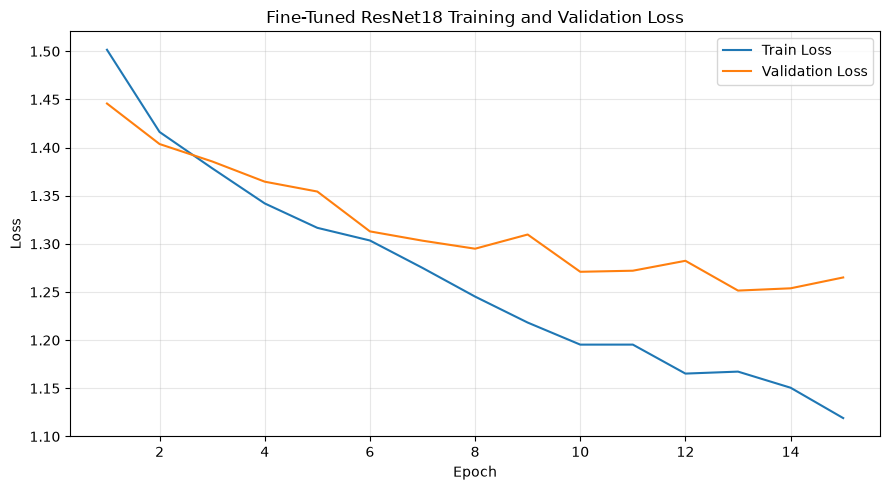

Saved: c:\Deep Learning\skin-lesion-classification\outputs\figures\fine_tuned_resnet18_loss_curve.png


In [25]:
# ------------------------------------------------------------
# Plot loss curves
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Fine-Tuned ResNet18 "
    "Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LOSS_FIGURE = (
    PROJECT_ROOT
    / config["outputs"]["loss_figure"]
)

plt.savefig(
    LOSS_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    LOSS_FIGURE,
)


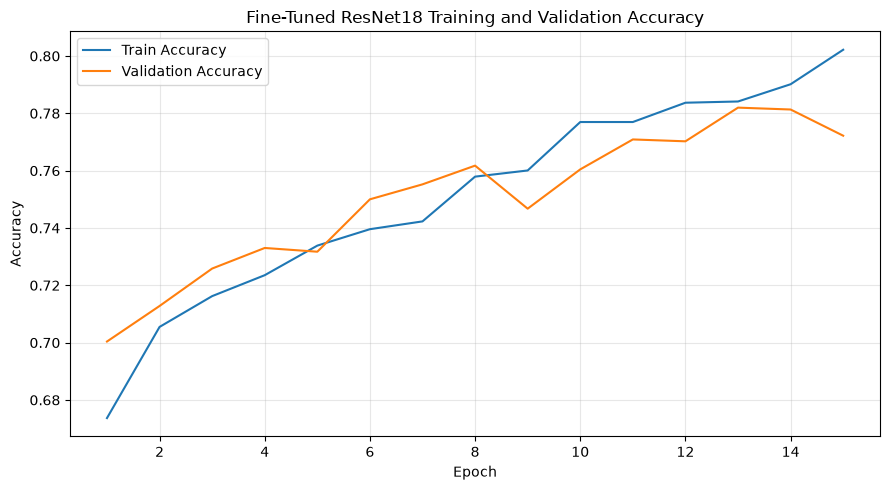

Saved: c:\Deep Learning\skin-lesion-classification\outputs\figures\fine_tuned_resnet18_accuracy_curve.png


In [26]:
# ------------------------------------------------------------
# Plot accuracy curves
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    fine_tune_history_df["epoch"],
    fine_tune_history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Fine-Tuned ResNet18 "
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ACCURACY_FIGURE = (
    PROJECT_ROOT
    / config["outputs"]["accuracy_figure"]
)

plt.savefig(
    ACCURACY_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    ACCURACY_FIGURE,
)


## Output artifacts

After this notebook finishes successfully, the important outputs are:

```text
outputs/
├── checkpoints/
│   └── fine_tuned_resnet18_best.pt
├── metrics/
│   └── fine_tuned_resnet18_training_history.csv
└── figures/
    ├── fine_tuned_resnet18_loss_curve.png
    └── fine_tuned_resnet18_accuracy_curve.png
```

`fine_tuned_resnet18_best.pt` should be used in **Part 9 — Evaluation**.

Do not select models using the test set.


## Proposed Fine-Tuned ResNet-18 Architecture

```text
Input RGB dermoscopic image
        3 x 224 x 224
              |
              v
+-----------------------------+
| Conv1: 7x7, 64, stride 2    |   FROZEN
| BatchNorm + ReLU            |
| MaxPool: 3x3, stride 2      |
+-----------------------------+
              |
          64 x 56 x 56
              |
              v
+-----------------------------+
| Layer 1                     |   FROZEN
| 2 x Basic Residual Blocks   |
| 64 channels                 |
+-----------------------------+
              |
          64 x 56 x 56
              |
              v
+-----------------------------+
| Layer 2                     |   FROZEN
| 2 x Basic Residual Blocks   |
| 128 channels                |
+-----------------------------+
              |
         128 x 28 x 28
              |
              v
+-----------------------------+
| Layer 3                     |   FROZEN
| 2 x Basic Residual Blocks   |
| 256 channels                |
+-----------------------------+
              |
         256 x 14 x 14
              |
              v
+=================================+
| Layer 4                         |   FINE-TUNED
| 2 x Basic Residual Blocks       |
| 512 channels                    |
+=================================+
              |
          512 x 7 x 7
              |
              v
+-----------------------------+
| Global Average Pooling      |
| 512 x 1 x 1                 |
+-----------------------------+
              |
              v
         Flatten: 512
              |
              v
+=================================+
| Dropout(p = 0.3)                |   TRAINABLE
| Linear: 512 -> 7                |
+=================================+
              |
              v
        7 output logits
              |
              v
HAM10000 classes:
akiec, bcc, bkl, df, mel, nv, vasc
```

### Architectural idea

The model keeps the early and intermediate ResNet-18 stages frozen because these layers
already provide transferable low-level and mid-level visual representations learned
from ImageNet. Only `layer4`, which contains the most task-specific high-level feature
representations, is unfrozen. This allows the network to learn dermoscopic patterns
such as lesion structure, pigmentation, texture, and boundary characteristics without
fully retraining the entire backbone.

The original ImageNet classifier is replaced by:

`Dropout(0.3) -> Linear(512, 7)`

The final layer outputs seven raw logits. No Softmax layer is included in the network
because `CrossEntropyLoss` operates directly on logits.


## Report-ready description

### Fine-Tuning Strategy

After the initial transfer-learning stage, the best ResNet-18 checkpoint was used as
the starting point for fine-tuning. In the transfer-learning stage, the pretrained
convolutional backbone was completely frozen and only the newly added seven-class
classifier was optimized. This produced a useful baseline, but the frozen ImageNet
features could not fully adapt to the visual characteristics of dermoscopic images.

To improve task-specific representation learning, the final residual stage (`layer4`)
of ResNet-18 was unfrozen while the earlier stages (`conv1`, `layer1`, `layer2`, and
`layer3`) remained frozen. The classifier also remained trainable. This progressive
fine-tuning strategy allows high-level features to adapt to lesion-specific structures,
pigmentation patterns, textures, and boundaries while preserving general low-level
features and reducing the risk of catastrophic forgetting.

Discriminative learning rates were used during optimization. A learning rate of
`1e-5` was assigned to `layer4`, while the newly initialized classifier used a larger
learning rate of `1e-4`. AdamW with weight decay of `1e-4` was selected to provide
stable optimization and regularization.

Because HAM10000 is strongly imbalanced, the original inverse-frequency class weights
were softened by taking their square root. This prevents extremely rare classes from
dominating the optimization while still assigning them greater importance than the
majority class. A label-smoothing value of `0.05` was additionally used to reduce
over-confident predictions and improve generalization.

The learning rate was reduced when validation loss stopped improving, and early
stopping was applied to limit overfitting. The model checkpoint with the lowest
validation loss was retained for the final evaluation on the held-out test set.
